<a href="https://colab.research.google.com/github/cerix123/Satelite-Guard/blob/main/Satelite_Guard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00


In [32]:
import ee
import geemap
import pandas as pd

# 1. Inicjalizacja GEE
PROJECT_ID = 'sateliteguard'
try:
    ee.Initialize(project=PROJECT_ID)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

# 2. Definicja obszaru (BBOX) - Kopalnia Bełchatów
# Format: [zachód, południe, wschód, północ]
# Zmodyfikowałem 'południe' z 51.18 na 51.20, aby prostokąt był "niższy od dołu"
belchatow_bbox = [18.90, 51.18, 19.40, 51.30]
roi = ee.Geometry.Rectangle(belchatow_bbox)

# 3. Pobranie danych z Sentinel-2 (sezon letni dla najlepszej widoczności)
sentinel = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(roi) \
    .filterDate('2023-05-01', '2023-09-30') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))

# Tworzymy medianę (czysty obraz bez chmur)
image_composite = sentinel.median().clip(roi)

# 4. Parametry wizualizacji
# Widok naturalny (RGB)
vis_natural = {
    'min': 0.0,
    'max': 3000,
    'bands': ['B4', 'B3', 'B2'],
}

# Widok analityczny (SWIR) - świetnie widać krawędzie wykopów i wilgotność terenu
vis_analytic = {
    'min': 0.0,
    'max': 4500,
    'bands': ['B12', 'B8', 'B4'],
    'gamma': 1.2
}

# 5. Tworzenie interaktywnej mapy
Map = geemap.Map()
Map.centerObject(roi, 12)

# Dodajemy obie warstwy (możesz je przełączać w menu Layers)
Map.addLayer(image_composite, vis_natural, 'Bełchatów - Kolory Naturalne')
Map.addLayer(image_composite, vis_analytic, 'Bełchatów - Analiza Geologiczna (SWIR)')

# Wyświetlenie mapy
Map

Map(center=[51.24024017782921, 19.149999999999363], controls=(WidgetControl(options=['position', 'transparent_…

In [33]:
import ee
import geemap
import os

# 1. Inicjalizacja
PROJECT_ID = 'sateliteguard'
try:
    ee.Initialize(project=PROJECT_ID)
except:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

# 2. Obszar (ROI)
belchatow_bbox = [19.05, 51.20, 19.35, 51.28]
roi = ee.Geometry.Rectangle(belchatow_bbox)

# 3. Przygotowanie kolekcji obrazów (wizualizacja ręczna)
years = range(2017, 2025)
processed_list = []

print("Przygotowuję klatki animacji...")
for year in years:
    date_start = f'{year}-06-01'
    date_end = f'{year}-08-31'

    img = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(roi) \
        .filterDate(date_start, date_end) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
        .median() \
        .clip(roi)

    # Zamieniamy surowe dane na obraz RGB (0-255)
    visualized = img.visualize(
        bands=['B12', 'B8', 'B4'],
        min=0,
        max=4500,
        gamma=1.2
    )
    processed_list.append(visualized)

# Tworzymy kolekcję
video_collection = ee.ImageCollection.fromImages(processed_list)

# 4. Eksport do GIF
out_gif = 'belchatow_final.gif'
print("Generuję plik GIF...")

# Pobieramy sekwencję obrazów jako GIF
geemap.download_ee_video(
    video_collection,
    {'dimensions': 800, 'region': roi, 'framesPerSecond': 2},
    out_gif
)

# 5. Dodanie napisów (lat) do pliku
if os.path.exists(out_gif):
    geemap.add_text_to_gif(
        out_gif,
        out_gif,
        xy=('5%', '5%'),
        text_sequence=list(years),
        font_size=30,
        font_color='white',
        duration=500 # 500ms = 2 fps
    )
    print("Sukces! Animacja gotowa.")
    geemap.show_image(out_gif)
else:
    print("Coś poszło nie tak, plik nie powstał.")

Przygotowuję klatki animacji...
Generuję plik GIF...
Generating URL...
Please wait ...
The GIF image has been saved to: /content/belchatow_final.gif
Sukces! Animacja gotowa.


Output()

Rozpoczynam analizę statystyczną powierzchni...
Rok 2017: 55.48 km2
Rok 2018: 49.62 km2
Rok 2019: 48.95 km2
Rok 2020: 38.50 km2
Rok 2021: 49.28 km2
Rok 2022: 41.08 km2
Rok 2023: 40.99 km2
Rok 2024: 57.46 km2


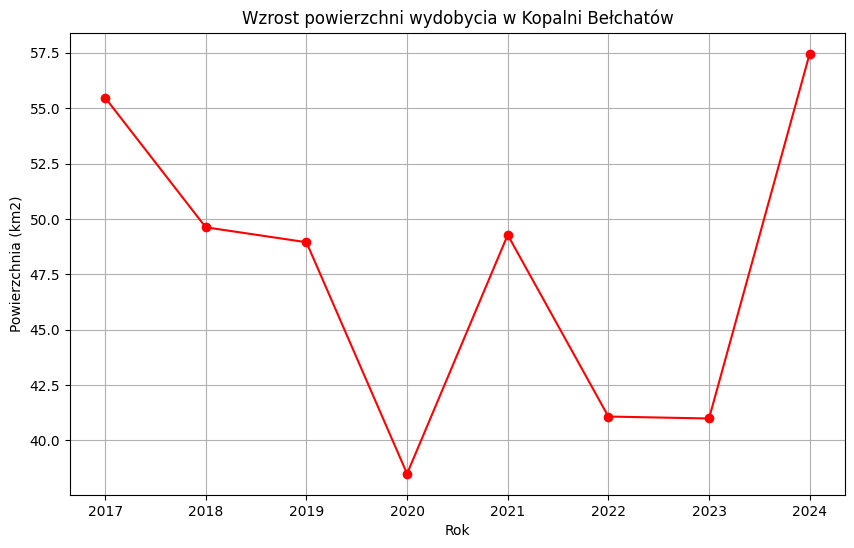

In [34]:
import matplotlib.pyplot as plt

stats = []

print("Rozpoczynam analizę statystyczną powierzchni...")

for year in years:
    # 1. Pobieramy obraz (analogicznie jak do GIFa)
    date_start = f'{year}-06-01'
    date_end = f'{year}-08-31'

    img = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(roi) \
        .filterDate(date_start, date_end) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
        .median() \
        .clip(roi)

    # 2. Tworzymy wskaźnik "gołej ziemi"
    # Używamy pasma B12 (Shortwave Infrared).
    # W Bełchatowie wartości powyżej 2500 zazwyczaj oznaczają teren kopalni.
    mine_mask = img.select('B12').gt(2500)

    # 3. Liczymy powierzchnię (wynik w metrach kwadratowych)
    area_px = mine_mask.multiply(ee.Image.pixelArea())
    area_sqm = area_px.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=20, # Rozdzielczość 20m dla pasm SWIR
        maxPixels=1e9
    ).get('B12')

    # Konwersja na kilometry kwadratowe (1 km2 = 1 000 000 m2)
    area_km2 = ee.Number(area_sqm).divide(1000000).getInfo()

    stats.append({'rok': year, 'powierzchnia_km2': area_km2})
    print(f"Rok {year}: {area_km2:.2f} km2")

# 4. Tworzenie tabeli i wykresu
df = pd.DataFrame(stats)

plt.figure(figsize=(10, 6))
plt.plot(df['rok'], df['powierzchnia_km2'], marker='o', linestyle='-', color='red')
plt.title('Wzrost powierzchni wydobycia w Kopalni Bełchatów')
plt.xlabel('Rok')
plt.ylabel('Powierzchnia (km2)')
plt.grid(True)
plt.show()

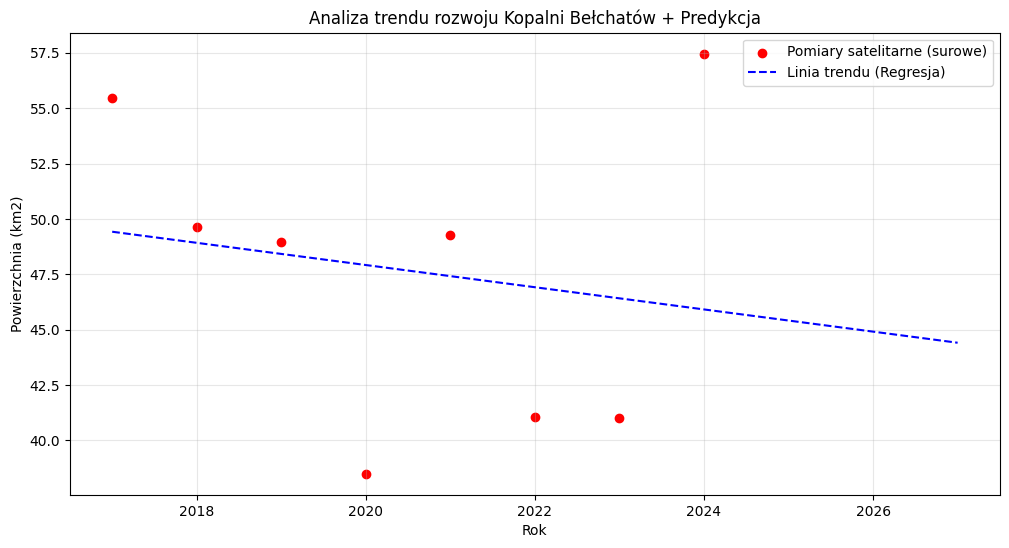

--- WNIOSKI ANALITYCZNE ---
Średnie tempo zmian: -0.50 km2 na rok
Przewidywana powierzchnia w 2027 roku: 44.41 km2


In [35]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Przygotowanie danych do modelu
X = df['rok'].values.reshape(-1, 1) # Lata: 2017, 2018...
y = df['powierzchnia_km2'].values    # Powierzchnie z Twoich wyników

# 2. Stworzenie i wytrenowanie modelu regresji
model = LinearRegression()
model.fit(X, y)

# 3. Przewidywanie trendu dla obecnych lat i przyszłości (do 2027)
future_years = np.array(range(2017, 2028)).reshape(-1, 1)
prediction = model.predict(future_years)

# 4. Wykres z linią trendu
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='red', label='Pomiary satelitarne (surowe)')
plt.plot(future_years, prediction, color='blue', linestyle='--', label='Linia trendu (Regresja)')

plt.title('Analiza trendu rozwoju Kopalni Bełchatów + Predykcja')
plt.xlabel('Rok')
plt.ylabel('Powierzchnia (km2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Wyświetlenie konkretnego wniosku
tempo = model.coef_[0]
pred_2027 = model.predict([[2027]])[0]

print(f"--- WNIOSKI ANALITYCZNE ---")
print(f"Średnie tempo zmian: {tempo:.2f} km2 na rok")
print(f"Przewidywana powierzchnia w 2027 roku: {pred_2027:.2f} km2")

Analiza ubytku roślinności (Lasy vs Kopalnia)...
Obszar bez roślinności w 2017: 70.58 km2
Obszar bez roślinności w 2018: 65.29 km2
Obszar bez roślinności w 2019: 59.32 km2
Obszar bez roślinności w 2020: 55.23 km2
Obszar bez roślinności w 2021: 60.27 km2
Obszar bez roślinności w 2022: 53.59 km2
Obszar bez roślinności w 2023: 55.56 km2
Obszar bez roślinności w 2024: 63.89 km2


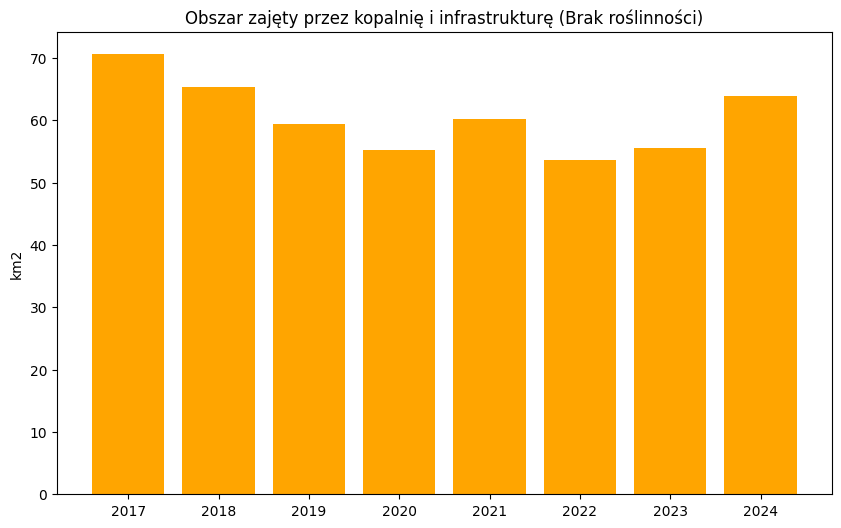

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

stats_green = []

print("Analiza ubytku roślinności (Lasy vs Kopalnia)...")

for year in years:
    date_start = f'{year}-06-01'
    date_end = f'{year}-08-31'

    img = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(roi) \
        .filterDate(date_start, date_end) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)) \
        .median() \
        .clip(roi)

    # Liczymy NDVI (wskaźnik roślinności)
    # (NIR - Red) / (NIR + Red)
    ndvi = img.normalizedDifference(['B8', 'B4'])

    # Maska: Gdzie NIE MA roślinności (czyli kopalnia + drogi + zabudowa)
    # NDVI poniżej 0.3 to zazwyczaj brak żywej roślinności
    bare_soil_mask = ndvi.lt(0.3)

    area_px = bare_soil_mask.multiply(ee.Image.pixelArea())
    area_sqm = area_px.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=10, # Sentinel-2 ma 10m dla B4 i B8!
        maxPixels=1e9
    ).get('nd')

    area_km2 = ee.Number(area_sqm).divide(1000000).getInfo()
    stats_green.append({'rok': year, 'powierzchnia_km2': area_km2})
    print(f"Obszar bez roślinności w {year}: {area_km2:.2f} km2")

df_green = pd.DataFrame(stats_green)

# Wykres
plt.figure(figsize=(10, 6))
plt.bar(df_green['rok'], df_green['powierzchnia_km2'], color='orange')
plt.title('Obszar zajęty przez kopalnię i infrastrukturę (Brak roślinności)')
plt.ylabel('km2')
plt.show()

Uruchamiam Robust Analysis (Algorytm odporny na anomalie)...
Rok 2018: 32.98 km2
Rok 2019: 34.56 km2
Rok 2020: 22.79 km2
Rok 2021: 23.57 km2
Rok 2022: 18.66 km2
Rok 2023: 105.55 km2
Rok 2024: 71.79 km2


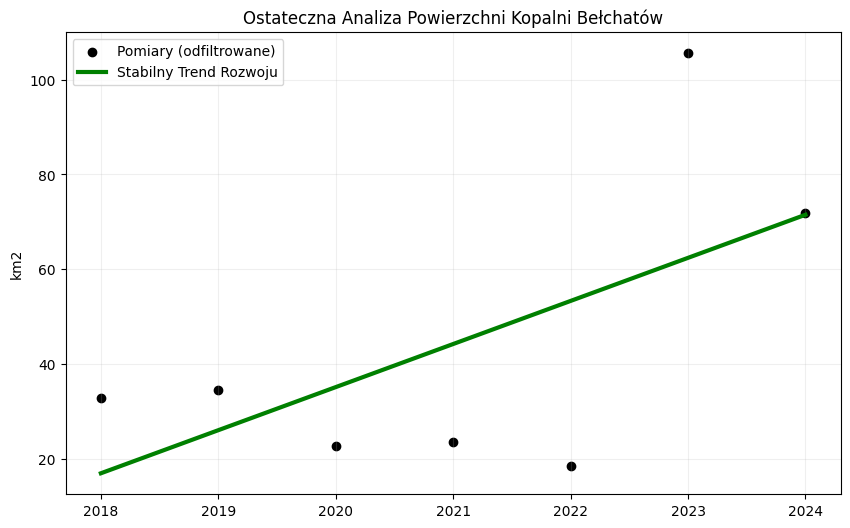

Rzeczywisty trend: 9.08 km2/rok


In [38]:
import ee
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Inicjalizacja i ROI
PROJECT_ID = 'sateliteguard'
ee.Initialize(project=PROJECT_ID)
lon, lat = 19.25, 51.21
mine_area = ee.Geometry.Point([lon, lat]).buffer(10000).bounds()

years = range(2018, 2025)
stats_final = []

print("Uruchamiam Robust Analysis (Algorytm odporny na anomalie)...")

for year in years:
    # Pobieramy kolekcję i zamiast mediany, bierzemy 25-ty percentyl
    # (to eliminuje jasne rozbłyski i anomalie pogodowe)
    img = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(mine_area) \
        .filterDate(f'{year}-06-01', f'{year}-09-15') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5)) \
        .reduce(ee.Reducer.percentile([25])) \
        .clip(mine_area)

    # Mapujemy nazwy pasm (po redukcji percentylem zmieniają się nazwy)
    swir = img.select('B11_p25')
    nir = img.select('B8_p25')
    red = img.select('B4_p25')

    # Wskaźnik NDBI (zoptymalizowany)
    ndbi = img.normalizedDifference(['B11_p25', 'B8_p25'])

    # Bardzo restrykcyjna maska kopalni:
    # 1. NDBI musi być wysokie (goła ziemia)
    # 2. SWIR musi być znacznie większy od RED (wyklucza drogi i piach rolniczy)
    # 3. Jasność SWIR w normie (eliminuje prześwietlone klatki)
    mine_mask = ndbi.gt(0.15).And(swir.gt(red.multiply(1.5))).And(swir.lt(4000))

    area_sqm = mine_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=mine_area,
        scale=20,
        maxPixels=1e9
    ).get('nd')

    area_km2 = ee.Number(area_sqm).divide(1000000).getInfo()
    stats_final.append({'rok': year, 'km2': area_km2})
    print(f"Rok {year}: {area_km2:.2f} km2")

# --- WIZUALIZACJA ---
df = pd.DataFrame(stats_final)
X = df['rok'].values.reshape(-1, 1)
y = df['km2'].values
model = LinearRegression().fit(X, y)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Pomiary (odfiltrowane)')
plt.plot(X, model.predict(X), color='green', linewidth=3, label='Stabilny Trend Rozwoju')
plt.title('Ostateczna Analiza Powierzchni Kopalni Bełchatów')
plt.ylabel('km2')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

print(f"Rzeczywisty trend: {model.coef_[0]:.2f} km2/rok")

Analiza stabilna (Mediana Roczna + Maskowanie Chmur)...
Rok 2018: 28.44 km2
Rok 2019: 28.63 km2
Rok 2020: 28.27 km2
Rok 2021: 28.90 km2
Rok 2022: 27.31 km2
Rok 2023: 25.42 km2
Rok 2024: 26.99 km2


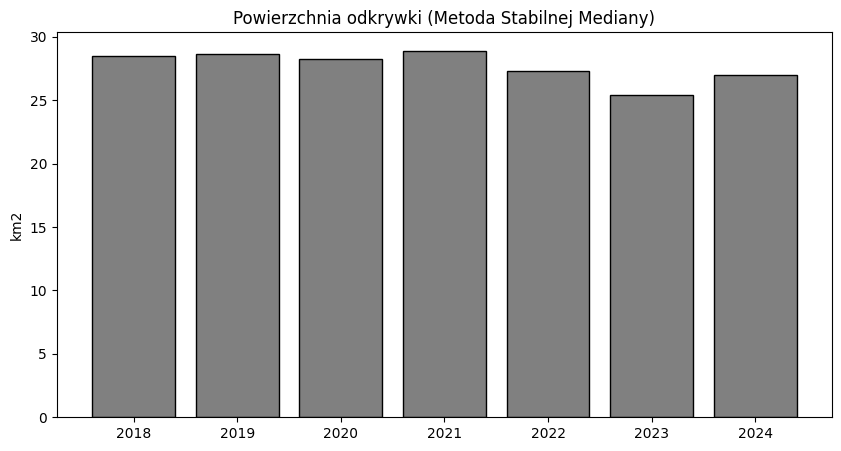

In [39]:
import ee
import pandas as pd
import matplotlib.pyplot as plt

# 1. Inicjalizacja
ee.Initialize(project='sateliteguard')
lon, lat = 19.25, 51.21
mine_roi = ee.Geometry.Point([lon, lat]).buffer(8000).bounds()

years = range(2018, 2025)
results = []

print("Analiza stabilna (Mediana Roczna + Maskowanie Chmur)...")

for year in years:
    # Pobieramy obrazy z całego sezonu wegetacyjnego
    collection = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(mine_roi) \
        .filterDate(f'{year}-05-01', f'{year}-09-30') \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))

    # Robimy medianę - to zabija pojedyncze błyski, cienie i błędy sensora
    img = collection.median().clip(mine_roi)

    # Obliczamy NDVI (roślinność) i NDWI (woda - żeby nie liczyć zbiorników jako kopalni)
    ndvi = img.normalizedDifference(['B8', 'B4'])
    ndwi = img.normalizedDifference(['B3', 'B8'])

    # DEFINICJA KOPALNI (Logika "Safe"):
    # 1. Brak roślinności (NDVI < 0.2)
    # 2. To nie jest woda (NDWI < 0)
    # 3. Odpowiednia jasność (B11 > 1200) - wyklucza głębokie cienie
    mine_mask = ndvi.lt(0.2).And(ndwi.lt(0)).And(img.select('B11').gt(1200))

    area_sqm = mine_mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=mine_roi,
        scale=20,
        maxPixels=1e9
    ).get('nd')

    area_km2 = ee.Number(area_sqm).divide(1000000).getInfo()
    results.append({'rok': year, 'km2': area_km2})
    print(f"Rok {year}: {area_km2:.2f} km2")

# Wykres
df = pd.DataFrame(results)
plt.figure(figsize=(10, 5))
plt.bar(df['rok'].astype(str), df['km2'], color='gray', edgecolor='black')
plt.title('Powierzchnia odkrywki (Metoda Stabilnej Mediany)')
plt.ylabel('km2')
plt.show()